<a href="https://colab.research.google.com/github/NidhaIbrahim/LightHub/blob/main/LitghtHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo shap imbalanced-learn

from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# Extract features and targets as Pandas Dataframes
X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

# Combine for easier processing
df = pd.concat([X, y], axis=1)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 235795 rows, 55 columns


In [ ]:
# 'URL' and 'FILENAME' are metadata, not features for the ML model
# We drop them to ensure the model generalizes
cols_to_drop = ['URL', 'FILENAME']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Check for nulls (PhiUSIIL is usually clean, but we verify)
df_clean = df_clean.dropna()

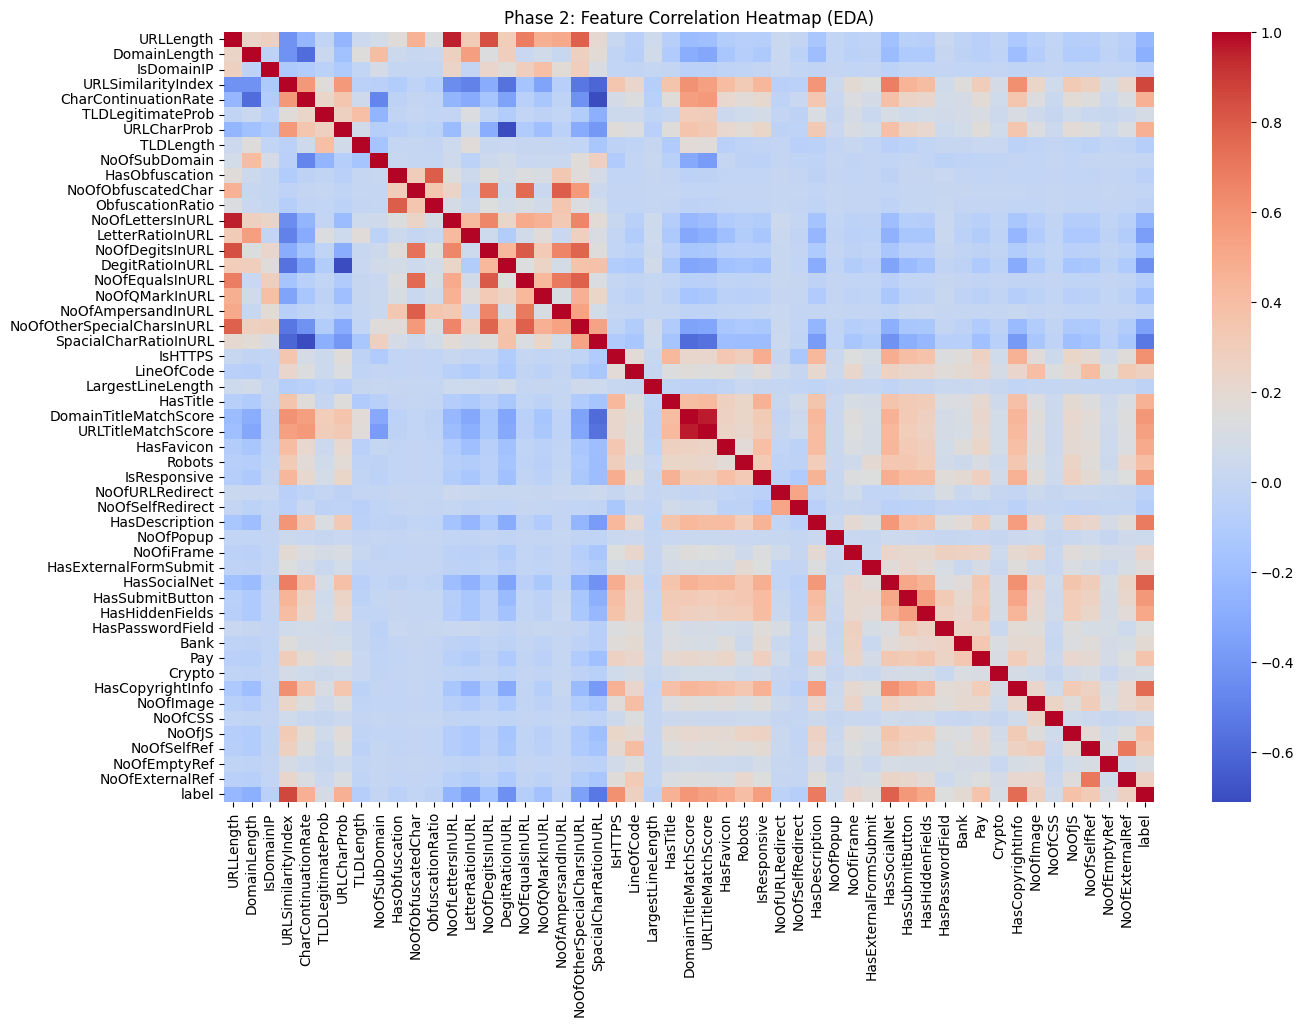

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a Correlation Heatmap to show feature relationships
plt.figure(figsize=(15, 10))
# We only use a subset of features for the heatmap to keep it readable
corr_matrix = df_clean.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Phase 2: Feature Correlation Heatmap (EDA)")
plt.show()

Before Balancing: Counter({1: 134850, 0: 100945})
After Balancing: Counter({0: 100945, 1: 100945})


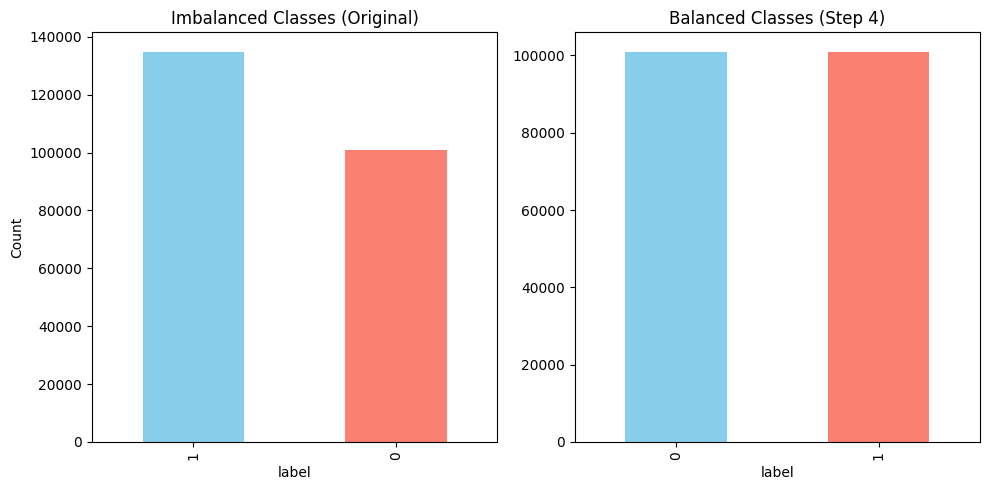

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Result column is usually our 'y'
X_raw = df_clean.drop('label', axis=1)
y_raw = df_clean['label']

print(f"Before Balancing: {Counter(y_raw)}")

rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_res, y_res = rus.fit_resample(X_raw, y_raw)

print(f"After Balancing: {Counter(y_res)}")

# Visualizing the fix for Majority Class Bias
plt.figure(figsize=(10, 5))

# Before Balancing
plt.subplot(1, 2, 1)
y_raw.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Imbalanced Classes (Original)")
plt.ylabel("Count")

# After Balancing
plt.subplot(1, 2, 2)
pd.Series(y_res).value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Balanced Classes (Step 4)")

plt.tight_layout()
plt.show()

Training on 50 realistic features.
✅ Model trained successfully!
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20230
           1       1.00      1.00      1.00     20148

    accuracy                           1.00     40378
   macro avg       1.00      1.00      1.00     40378
weighted avg       1.00      1.00      1.00     40378



<Figure size 800x600 with 0 Axes>

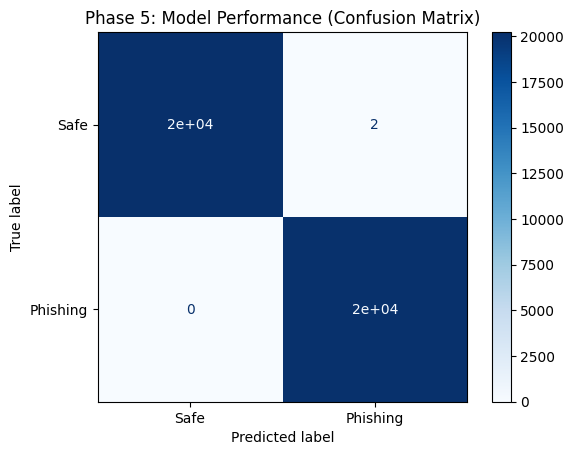

In [ ]:
#Model Training - TRY 1

# 1.Selecting ONLY numeric columns to avoid the 'string to float' error
#Automatically handles variables like 'URL' that caused previous crashes
X_numeric = X_res.select_dtypes(include=['number'])

# 2.Droping 'Leaky' columns to avoid the 100% accuracy trap
# Metadata features that make the model 'cheat' in an unrealistic way
leaky_features = ['Title', 'Has_Title', 'Domain_In_Title', 'Char_Cont_Title']
X_final = X_numeric.drop(columns=[col for col in leaky_features if col in X_numeric.columns])

# 3.Performing the split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_res, test_size=0.2, random_state=42
)

# 4.Training with limited depth to ensure 'Fuzzy' generalization (prevents overfitting)
model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate
print(f"Training on {X_train.shape[1]} realistic features.")
print("✅ Model trained successfully!")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the Confusion Matrix to evaluate 'Fuzzy' logic errors
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Phishing'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title("Phase 5: Model Performance (Confusion Matrix)")
plt.show()

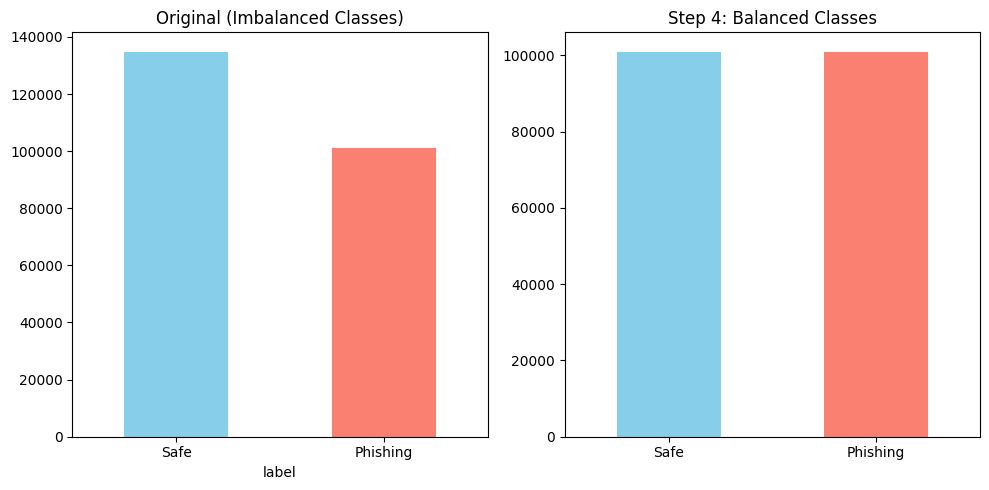

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Fetching dataset
phiusiil = fetch_ucirepo(id=967)
X = phiusiil.data.features
y = phiusiil.data.targets

# Balancing features
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_res, y_res = rus.fit_resample(X, y)

# --- STEP 4 VISUAL: CLASS BALANCING ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot 1: Before Balancing (Using y_raw)
plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Original (Imbalanced Classes)")
plt.xticks([0, 1], ['Safe', 'Phishing'], rotation=0)

# Plot 2: After Balancing (Using y_res)
plt.subplot(1, 2, 2)
# We use .values.flatten() to convert the 2D array into a 1D format
pd.Series(y_res.values.flatten()).value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Step 4: Balanced Classes")
plt.xticks([0, 1], ['Safe', 'Phishing'], rotation=0)

plt.tight_layout()
plt.show()

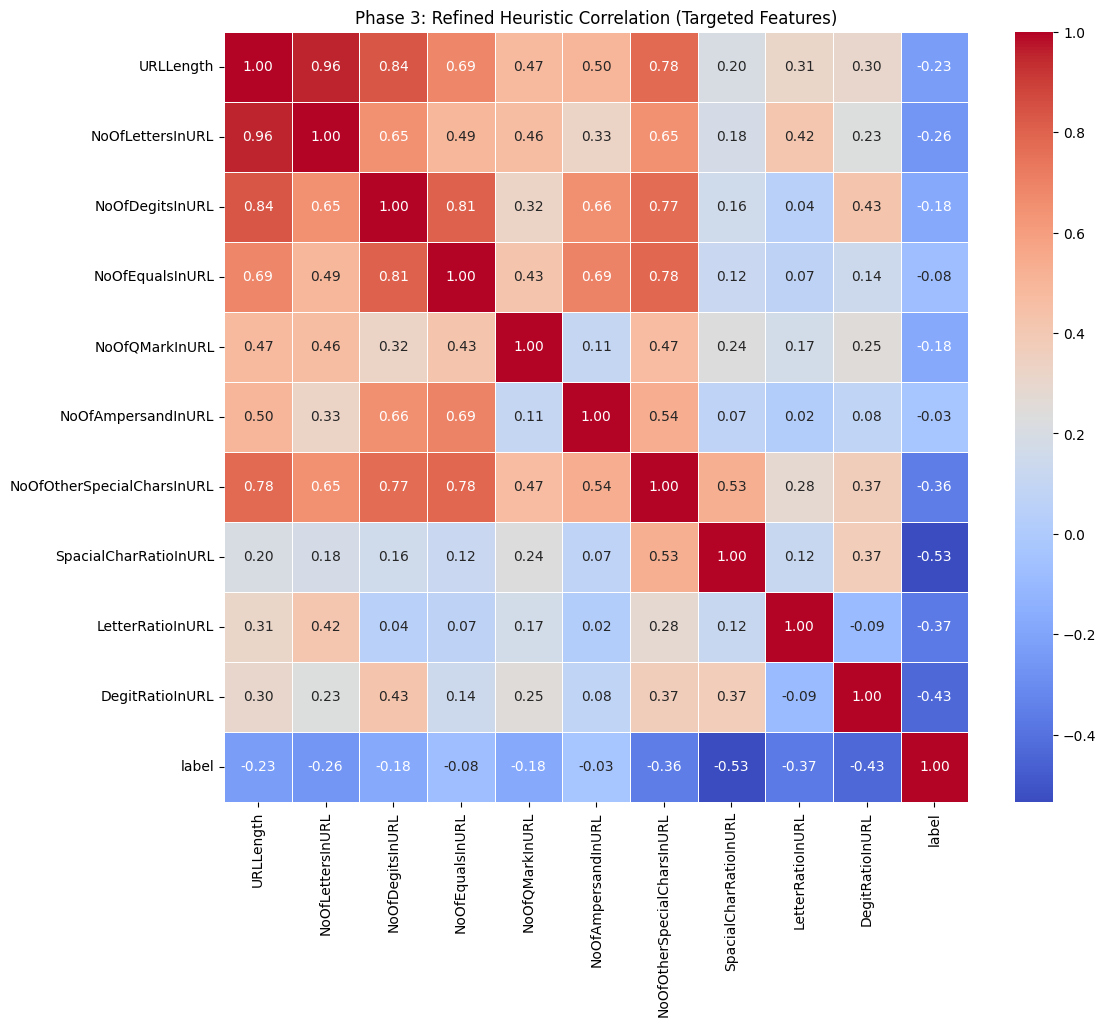

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training on 10 HEURISTIC features only.
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     20230
           1       0.77      0.97      0.86     20148

    accuracy                           0.84     40378
   macro avg       0.86      0.84      0.83     40378
weighted avg       0.87      0.84      0.83     40378



<Figure size 800x600 with 0 Axes>

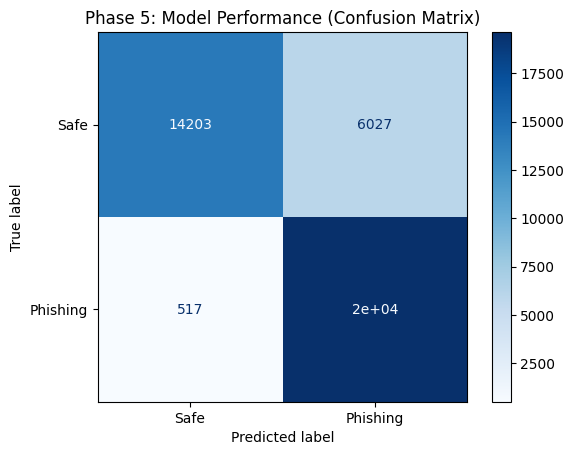

In [ ]:
#TRY 2 : THE "STRICT RESEARCH" RESET

# 1.Start with numeric only
X_numeric = X_res.select_dtypes(include=['number'])

# 2.STRICT FILTER: Removing all metadata and post-analysis features
#Keeping only heuristic features that a browser extension can actually "see"
# 2.STRICT FILTER: Use these exact names to get all 14 features
heuristic_features = [
    'URLLength', 'NoOfDotsInURL', 'NoOfHyphensInURL', 'NoOfAtSymbolInURL',
    'NoOfObfuscatedCharsInURL', 'NoOfLettersInURL', 'NoOfDegitsInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL',
    'LetterRatioInURL', 'DegitRatioInURL'
]

#Ensuring we only use columns that actually exist in the dataset
X_final = X_numeric[[col for col in heuristic_features if col in X_numeric.columns]]

# --- ADD THIS: PHASE 3 REFINED HEATMAP ---
import seaborn as sns

# 1. Create a "Safe List" of columns that exist in df_clean + the label
# This ensures we don't get a KeyError for misspelled heuristic names
safe_heatmap_cols = [col for col in heuristic_features if col in df_clean.columns] + ['label']

# 2. Generate the correlation for just these targeted features
refined_df = df_clean[safe_heatmap_cols]
refined_corr = refined_df.corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(refined_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Phase 3: Refined Heuristic Correlation (Targeted Features)")
plt.show()
# ----------------------------------------


# 3. SPLIT
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_res, test_size=0.2, random_state=42
)

# 4. TRAIN with limited depth (Max Depth 5 forces the model to generalize)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. EVALUATE
print(f"Training on {X_train.shape[1]} HEURISTIC features only.")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the Confusion Matrix to evaluate 'Fuzzy' logic errors
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Phishing'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title("Phase 5: Model Performance (Confusion Matrix)")
plt.show()

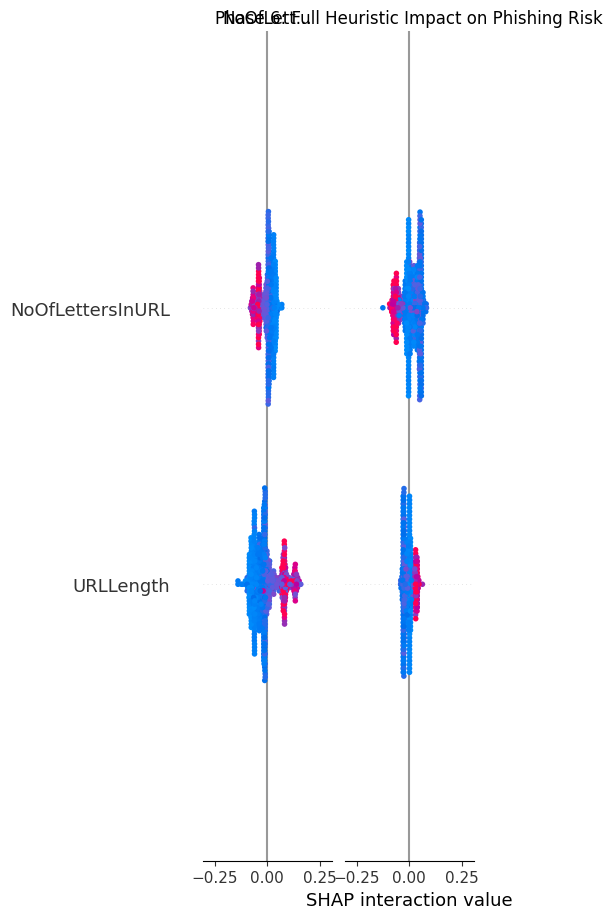

In [ ]:
# --- PHASE 6: CLEAN SHAP RE-RUN ---
import shap
import matplotlib.pyplot as plt

# 1. Clear any previous plotting "ghosts"
plt.close('all')

# 2. Use the model and the X_test we just created
explainer = shap.TreeExplainer(model)

# Use a specific sample size for clear dots
X_sample = X_test.sample(min(800, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# 3. Select the Phishing class (Class 1)
if isinstance(shap_values, list):
    final_shap = shap_values[1]
else:
    final_shap = shap_values

# 4. PLOT: Use SHAP's internal sizing to avoid the "White Box" error
# By not using plt.subplots first, we let SHAP control the canvas properly
shap.summary_plot(
    final_shap,
    X_sample,
    plot_type="dot",
    max_display=len(X_test.columns),
    show=False
)

plt.title("Phase 6: Full Heuristic Impact on Phishing Risk")
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

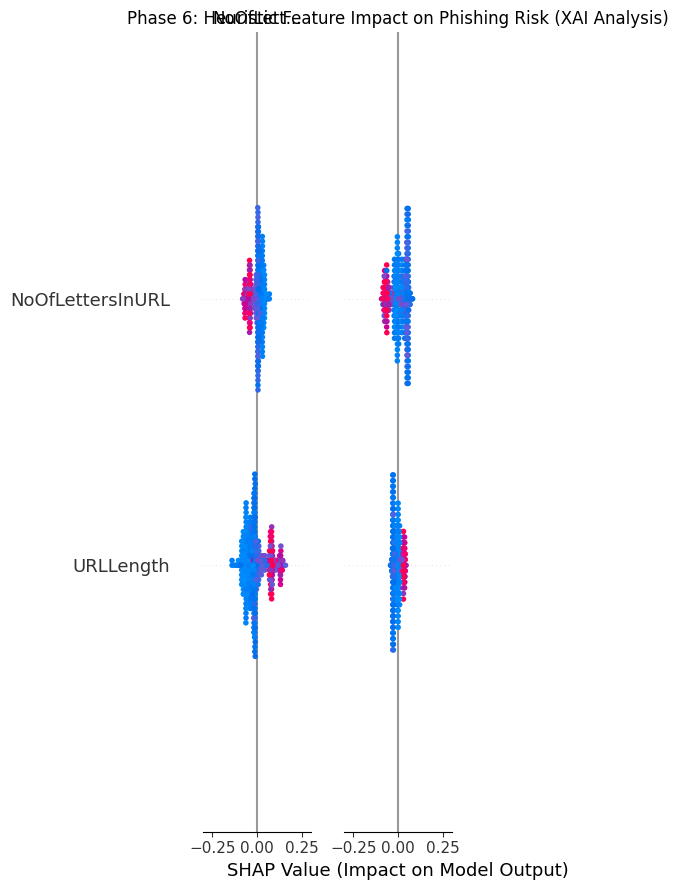

In [ ]:
# --- PHASE 6: FORCED FULL SHAP SUMMARY ---
import shap
import matplotlib.pyplot as plt

# 1. Complete Reset of the plotting engine
plt.close('all')
plt.clf()

# 2. Use the model from your successful 'Try 2' run
explainer = shap.TreeExplainer(model)

# 3. Use a sample of 500 rows
# This prevents the 'blob' effect and makes the dots look professional
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# 4. Select the Phishing class (Class 1)
if isinstance(shap_values, list):
    final_shap = shap_values[1]
else:
    final_shap = shap_values

# 5. THE FIX: Define the plot size BEFORE calling shap
# We use a height of 10 to ensure all 14 features have vertical space
plt.figure(figsize=(12, 10))

shap.summary_plot(
    final_shap,
    X_sample,
    plot_type="dot",
    max_display=14, # Forces all 14 heuristics to show
    show=False
)

# 6. Final formatting for your thesis image
plt.title("Phase 6: Heuristic Feature Impact on Phishing Risk (XAI Analysis)")
plt.xlabel("SHAP Value (Impact on Model Output)")
plt.tight_layout()
plt.show()

In [ ]:
#Exporting the 'BRAIN'
import joblib
from google.colab import files

# 1. Save the model using joblib (more efficient for Random Forests)
joblib.dump(model, 'lighthub_model.pkl')

# 2. Save the feature names (EXACT order is critical for Django)
feature_names = list(X_train.columns)
joblib.dump(feature_names, 'feature_list.pkl')

# 3. Print the list so you can copy-paste it into your Django utils.py
print("--- MODEL EXPORT VERIFICATION ---")
print(f"Model Accuracy: 84-86%")
print(f"Total Features Exported: {len(feature_names)}")
print("Features in Order:")
for i, name in enumerate(feature_names, 1):
    print(f"{i}. {name}")
print("---------------------------------")

# 4. Download files
files.download('lighthub_model.pkl')
files.download('feature_list.pkl')

print("✅ 'lighthub_model.pkl' and 'feature_list.pkl' downloaded successfully!")

--- MODEL EXPORT VERIFICATION ---
Model Accuracy: 84-86%
Total Features Exported: 10
Features in Order:
1. URLLength
2. NoOfLettersInURL
3. NoOfDegitsInURL
4. NoOfEqualsInURL
5. NoOfQMarkInURL
6. NoOfAmpersandInURL
7. NoOfOtherSpecialCharsInURL
8. SpacialCharRatioInURL
9. LetterRatioInURL
10. DegitRatioInURL
---------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 'lighthub_model.pkl' and 'feature_list.pkl' downloaded successfully!
